#<h1><center>Lab 1 - A1</center></h1>

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

## PROBLEMA RUCSACULUI

-	n obiecte, fiecare obiect are o valoare (v) şi o greutate (w)
-	Obiectiv: puneţi în rucsac valoarea maximă fără a depăşi greutatea maximă admisă W
-	xi=1 înseamnă obiectul i este pus în rucsac
-	xi=0 înseamnă obiectul i nu este pus în rucsac


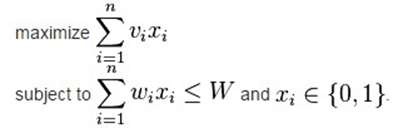

## 5	RANDOM HILL-CLIMBING (RHC)

1.	Se selectează un punct aleator c (current) în spaţiul de căutare
2.	Se alege un punct x din vecinătatea lui c: N(c).
Dacă eval(x) este mai bun decât eval(c) atunci c=x.
3.	Repetă pasul 2 până când un număr maxim de evaluări se atinge.
4.	Returnează c.


## Lucru în timpul laboratorului

1.	Completarea de cod în fișierul Jupyter Notebook (A1.ipynb) unde e notat cu **TODO**:
 1.	Definirea funcției de fitness/evaluare (10p)
 1.	Validarea unei soluții generate (10p)
 1.  Generare soluție prin vecinătate(10p)
 1.	Completarea algoritmului RHC (10p)
 1.	Completarea tabelului de date (10p)

**Total Punctaj A1-Lab = 50p**

**Deadline Lab 1**


### Încărcare date din fișier (10p)

In [ ]:
# definire încărcare date
def load_data(file_name: str) -> "tuple[list[tuple[int, int]], int]":
  """
  Citeste datele din fisierul file_name
  """
  weights_and_values = []
  with open(file_name) as f:
    nr_obj = int(f.readline())
    for i in range(nr_obj):
      line = f.readline()
      line = line.split(" ")
      line = [x for x in line if x != ""]
      weights_and_values.append(tuple(int(x) for x in line[1:]))
    max_capacity = int(f.readline())
  return weights_and_values, max_capacity
load_data("/content/rucsac-200.txt") # rucsac-20.txt and rucsac-200.txt

([(835, 735),
  (1670, 1470),
  (3340, 2940),
  (1087, 987),
  (1087, 987),
  (517, 417),
  (1034, 834),
  (2068, 1668),
  (1034, 834),
  (630, 530),
  (1260, 1060),
  (1260, 1060),
  (1071, 971),
  (165, 65),
  (330, 130),
  (495, 195),
  (176, 76),
  (663, 563),
  (1326, 1126),
  (1326, 1126),
  (984, 884),
  (1968, 1768),
  (2952, 2652),
  (829, 729),
  (1658, 1458),
  (3316, 2916),
  (829, 729),
  (663, 563),
  (1326, 1126),
  (1989, 1689),
  (1086, 986),
  (1086, 986),
  (639, 539),
  (1278, 1078),
  (2556, 2156),
  (1917, 1617),
  (895, 795),
  (1790, 1590),
  (3580, 3180),
  (888, 788),
  (1776, 1576),
  (3552, 3152),
  (2664, 2364),
  (232, 132),
  (464, 264),
  (928, 528),
  (464, 264),
  (472, 372),
  (944, 744),
  (691, 591),
  (1382, 1182),
  (2764, 2364),
  (1052, 952),
  (1052, 952),
  (1057, 957),
  (2114, 1914),
  (2114, 1914),
  (456, 356),
  (912, 712),
  (651, 551),
  (1302, 1102),
  (1953, 1653),
  (711, 611),
  (1422, 1222),
  (1042, 942),
  (232, 132),
  (464, 264

### Definire funcții de fitness/evaluare (10p) și generare (10p)

In [ ]:
# definire funcții de fitness/evaluare și generare

def is_valid(objects: list, sol: list, max_capacity: int):
  """
  Verifica validitatea unei solutii
  """
  weight = 0
  for i in range(len(objects)):
    if sol[i] == 1:
      weight += objects[i][0]
  return weight <= max_capacity

def generate_solution(n: int):
  """
  Genereaza o solutie aleatoare
  """
  return list(np.random.randint(2, size=n))


def generate_valid_solution(n: int, objects: list, max_capacity: int):
  """
  Genereaza o solutie valida aleatoare
  INPUT
  ------
  n: numarul de obiecte
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  sol: soluția generată
  """
  stop = False
  sol = []
  while not stop:
    sol = generate_solution(n)
    stop = is_valid(objects, sol, max_capacity)
  return sol

def fitness(objects: list, sol: list, max_capacity: int):
  """
  Evaluează o soluție pentru problema rucsacului.
  INPUT
  ------
  objects: obiectele care pot fi adăugate în rucsac
  sol: solutția drept o listă de 0 și 1 de lungimea numărului de obiecte
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  value: valoarea tutoror obiectelor care au fost adăugate în rucsac
        sau -1 dacă greutatea obiectelor trece peste greutatea maximă permisă
  """
  value = 0
  weight = 0
  for i in range(len(objects)):
    if sol[i] == 1:
      value += objects[i][1]
      weight += objects[i][0]
      if weight > max_capacity:
        return -1
  return value
fitness

<function __main__.fitness(objects: list, sol: list, max_capacity: int)>

### Completare algoritm RHC (10p)

In [ ]:
def random_neighbor(sol: list):
  """
  Generează un vecin aleatoriu pentru o soluție
  """
  x = sol[:]
  index = np.random.randint(len(sol)) # selecteaza indexul pentru bit flip
  x[index] = 1 - x[index] # bit flip
  return x

def random_hill_climbing(k: int, objects: list, max_capacity: int):
  """
  Algoritm RHC pentru problema rucsacului.
  INPUT
  ------
  k: numărul de iterații
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  -----
  c - cea mai bună soluție
  fc - fitness-ul acesteia
  found_solutions - lista cu fitness-urile de la o iterație la alta
  """
  c = generate_valid_solution(len(objects), objects, max_capacity)
  fc = fitness(objects, c, max_capacity) # fitness-ul soluției c
  found_solutions = [fc]
  while k > 0:
    x = random_neighbor(c)
    fx = fitness(objects, x, max_capacity) # fitness-ul soluției x
    if fx > fc:
      c = x[:]
      fc = fx
    found_solutions.append(fc) # adaugă fitness-ul celei mai bune soluții
    k -= 1
  return c, fc, found_solutions

In [ ]:
def rhc_n_times(n: int, k: int, objects: list, max_capacity: int):
  """
  Ruleaza algoritmul de n ori si returneaza cele mai bune solutii
  """
  best_solutions = []
  average_time = 0
  for _ in range(n):
    start = time.time()
    best_solution, best_fitness, _ = random_hill_climbing(k, objects, max_capacity)
    stop = time.time() - start
    average_time = stop
    best_solutions.append((best_solution, best_fitness))
  average_time /= n
  return best_solutions, average_time

problem_instances = ["rucsac-20.txt", "rucsac-200.txt"] # valorile din tabel
values_for_n = [10] # valorile din tabel
values_for_k = [50, 100, 200] # valorile din tabel

markdown_table = "| n | k | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---| \n"

for pi in problem_instances:
  objects, max_capacity = load_data(pi)
  for n in values_for_n:
    for k in values_for_k:
      best_results, average_time = rhc_n_times(n, k, objects, max_capacity)
      best = max(best_results, key=lambda x: x[1])
      average = sum([x[1] for x in best_results]) / len(best_results)
      markdown_table += f"| {pi} | {n} | {k} | {best[1]} | {average} | {average_time} |\n"

markdown_table # copy paste intr-o celula de text

'| n | k | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---| \n| rucsac-20.txt | 10 | 50 | 638 | 540.2 | 3.4308433532714845e-05 |\n| rucsac-20.txt | 10 | 100 | 650 | 595.6 | 8.270740509033203e-05 |\n| rucsac-20.txt | 10 | 200 | 719 | 598.3 | 0.0001302003860473633 |\n| rucsac-200.txt | 10 | 50 | 97472 | 96136.6 | 0.00017571449279785156 |\n| rucsac-200.txt | 10 | 100 | 96985 | 95758.3 | 0.0013627290725708007 |\n| rucsac-200.txt | 10 | 200 | 96752 | 95682.5 | 0.0006699085235595704 |\n'

| n | k | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|
| rucsac-20.txt | 10 | 50 | 654 | 546.6 | 5.3834915161132815e-05 |
| rucsac-20.txt | 10 | 100 | 663 | 555.4 | 0.00011675357818603515 |
| rucsac-20.txt | 10 | 200 | 682 | 599.7 | 0.00026683807373046876 |
| rucsac-200.txt | 10 | 50 | 96568 | 95764.1 | 0.0005654335021972656 |
| rucsac-200.txt | 10 | 100 | 96967 | 96137.1 | 0.0006359577178955078 |
| rucsac-200.txt | 10 | 200 | 96981 | 96124.6 | 0.0012027263641357423 |


| Instanța problemei | k | Valoare medie | Greutate medie | Best | Număr execuții | Timp |
| --- | --- | --- | --- | --- | --- | --- |
| Rucsac-20.txt | 50 | --- | --- | --- | 10 | --- |
|               | 100 | --- | --- | --- |  | --- |
|               | --- | --- | --- | --- |  | --- |
|               | 200 | --- | --- | --- |  | --- |
| Rucsac-200.txt | 50 | --- | --- | --- | 10 | --- |
|                | 100 | --- | --- | --- |  | --- |
|                | --- | --- | --- | --- |  | --- |
|                | 200 | --- | --- | --- |  | --- |

## A1-Temă

1.	Să se implementeze una din cele două variante rămase ale metodei Hill-Climbing pentru problema rucsacului (cf numar din grupa) (25p):
 *	Steepest Ascent Hill-Climbing (număr impar)
 *	Next Ascent Hill-Climbing (număr par)
1. Scrierea de documentație în Jupyter notebook sau într-un document word/pdf (25p)
 * Documentare cod
 * Explicarea funcțiilor pe pași
 * Tabel cu rezultate pentru fiecare instanță a problemei prentru minim 5 valori diferite
de parametri
 * Analiza rezultatelor
    * Comparație cu RHC

**Total Punctaj A1-Temă = 50p**

**Deadline Lab 2**


In [ ]:
# Tema 1: implementare SAHC

def all_neighbours(sol: list):
  """
  Genereaza toti vecinii pentru o solutie data
  INPUT: sol = solutia sub forma de lista de 0 si 1
  (0 = obiectul la aceeasi pozitie in lista de obiecte nu se afla in rucsac, 1 = obiectul se afla in rucsac)
  OUTPUT: neighbours = lista de vecini ai solutiei
  """
  neighbours = []
  x = sol[:] # initializam pe x cu solutia data (vom folosi variabila x pentru a gasi vecinii)
  for i in range(len(sol)):
    x = sol[:]
    x[i] = 1 - x[i] # bit flip pe rand la fiecare pozitie => gasim toti vecinii
    neighbours.append(x)
  return neighbours

def steepest_ascent_hill_climbing(k: int, objects: list, max_capacity: int):
  """
  Algoritm SAHC pentru problema rucsacului.
  INPUT:
  - k: numarul de iteratii
  - objects: obiectele care pot fi adaugate in rucsac
  - max_capacity: capacitatea maxima a rucsacului
  OUTPUT:
  - c: cea mai buna solutie
  - fc: fitness-ul acesteia
  - found_solutions: lista cu fitness-urile de la o iterație la alta
  """

  c = generate_valid_solution(len(objects), objects, max_capacity) # generam o solutie random
  fitness_c = fitness(objects, c, max_capacity) # fitness-ul soluției c
  found_solutions = [fitness_c]

  while k > 0:
    vecini = all_neighbours(c) # generam toti vecinii solutiei c
    cel_mai_fit_vecin = [] # aici o sa fie stored vecinul cu cel mai bun fitness
    best_fitness = 0 # aici o sa fie stored best fitness in the neighbourhood

    for vecin in vecini:
      fitness_vecin = fitness(objects, vecin, max_capacity) # calculam fitness-ul fiecarui vecin
      if fitness_vecin > best_fitness: # daca fitness-ul vecinului este mai bun atunci actualizam best_fitness si cel_mai_fit_vecin
        cel_mai_fit_vecin = vecin[:]
        best_fitness = fitness_vecin

    if best_fitness > fitness_c: # daca fitness-ul celui mai bun vecin este mai bun decat fitness-ul solutiei c
      c = cel_mai_fit_vecin[:] # atunci actualizam solutia c
      fitness_c = best_fitness # si fitness-ul solutiei c
      found_solutions.append(fitness_c) # adaugam fitness-ul celei mai bune solutii la lista de solutii gasite
    elif k > 0: # daca nu am gasit un fitness mai bun si mai avem iteratii ramase:
      c = generate_valid_solution(len(objects), objects, max_capacity) # generam o alta solutie random
      fitness_c = fitness(objects, c, max_capacity) # aflam fitness-ul solutiei noi

    k -= 1

  return c, fitness_c, found_solutions

def sahc_n_times(n: int, k: int, objects: list, max_capacity: int):
  """
  Ruleaza algoritmul SAHC de n ori si returneaza cele mai bune solutii

  INPUT:
  - n: numarul de rulari ale algoritmului SAHC
  - k: numarul de iteratii
  - objects: obiectele care pot fi adaugate in rucsac
  - max_capacity: capacitatea maxima a rucsacului
  OUTPUT:
  - best_solutions: lista cu cele mai bune solutii
  - average_time: timpul mediu de executie
  """
  best_solutions = []
  average_time = 0
  for _ in range(n):
    start = time.time()
    best_solution, best_fitness, _ = steepest_ascent_hill_climbing(k, objects, max_capacity)
    stop = time.time() - start
    average_time = stop
    best_solutions.append((best_solution, best_fitness))
  average_time /= n
  return best_solutions, average_time

problem_instances = ["rucsac-20.txt", "rucsac-200.txt"] # instantele problemei
values_for_n = [5, 10, 15] # de cate ori rulam algoritmul
values_for_k = [50, 100, 150, 200, 250] # numarul de iteratii din cadrul algoritmului

markdown_table = "| n | k | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---| \n"

for pi in problem_instances:
  objects, max_capacity = load_data(pi)
  for n in values_for_n:
    for k in values_for_k:
      best_results, average_time = sahc_n_times(n, k, objects, max_capacity)
      best = max(best_results, key=lambda x: x[1])
      average = sum([x[1] for x in best_results]) / len(best_results)
      markdown_table += f"| {pi} | {n} | {k} | {best[1]} | {average} | {average_time} |\n"

markdown_table # copy paste intr-o celula de text

'| n | k | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---| \n| rucsac-20.txt | 5 | 50 | 762 | 568.8 | 0.0007708549499511718 |\n| rucsac-20.txt | 5 | 100 | 659 | 550.8 | 0.0016131401062011719 |\n| rucsac-20.txt | 5 | 150 | 673 | 577.6 | 0.0020255565643310545 |\n| rucsac-20.txt | 5 | 200 | 729 | 493.0 | 0.002685737609863281 |\n| rucsac-20.txt | 5 | 250 | 787 | 689.0 | 0.0035255908966064452 |\n| rucsac-20.txt | 10 | 50 | 716 | 630.7 | 0.0004953622817993164 |\n| rucsac-20.txt | 10 | 100 | 670 | 574.1 | 0.0011682510375976562 |\n| rucsac-20.txt | 10 | 150 | 776 | 535.6 | 0.0012891054153442382 |\n| rucsac-20.txt | 10 | 200 | 705 | 562.0 | 0.0015472412109375 |\n| rucsac-20.txt | 10 | 250 | 738 | 566.3 | 0.0015735864639282227 |\n| rucsac-20.txt | 15 | 50 | 716 | 500.26666666666665 | 0.00023245811462402344 |\n| rucsac-20.txt | 15 | 100 | 739 | 570.0 | 0.00044535001118977866 |\n| rucsac-20.txt | 15 | 150 | 701 | 530.0 | 0.000815884272257487 |\n| rucsac-20.txt | 15 | 200 | 710 | 5

| n | k | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|
| rucsac-20.txt | 10 | 50 | 686 | 508.1 | 0.0007297039031982422 |
| rucsac-20.txt | 10 | 100 | 618 | 547.6 | 0.0006346702575683594 |
| rucsac-20.txt | 10 | 200 | 737 | 574.3 | 0.0012117862701416016 |
| rucsac-20.txt | 10 | 250 | 736 | 582.1 | 0.0015560150146484374 |
| rucsac-20.txt | 10 | 300 | 755 | 539.8 | 0.0018099546432495117 |
| rucsac-200.txt | 10 | 50 | 96132 | 93284.0 | 0.026654720306396484 |
| rucsac-200.txt | 10 | 100 | 96677 | 93755.4 | 0.052312803268432614 |
| rucsac-200.txt | 10 | 200 | 97040 | 94227.6 | 0.10768556594848633 |
| rucsac-200.txt | 10 | 250 | 96914 | 94533.2 | 0.12856764793395997 |
| rucsac-200.txt | 10 | 300 | 96772 | 94711.8 | 0.16297516822814942 |


| n | k | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|
| rucsac-20.txt | 10 | 50 | 714 | 488.7 | 0.0003376483917236328 |
| rucsac-20.txt | 10 | 100 | 676 | 571.9 | 0.0006693363189697266 |
| rucsac-20.txt | 10 | 150 | 739 | 582.9 | 0.0010810375213623046 |
| rucsac-20.txt | 10 | 200 | 679 | 559.7 | 0.00172731876373291 |
| rucsac-20.txt | 10 | 250 | 675 | 554.3 | 0.0017361164093017579 |
| rucsac-20.txt | 10 | 300 | 749 | 588.3 | 0.002041149139404297 |
| rucsac-200.txt | 10 | 50 | 96682 | 95594.2 | 0.027886509895324707 |
| rucsac-200.txt | 10 | 100 | 96719 | 94582.2 | 0.05689394474029541 |
| rucsac-200.txt | 10 | 150 | 96330 | 93975.8 | 0.12632439136505128 |
| rucsac-200.txt | 10 | 200 | 97326 | 93413.8 | 0.21737339496612548 |
| rucsac-200.txt | 10 | 250 | 96247 | 93281.2 | 0.14594542980194092 |
| rucsac-200.txt | 10 | 300 | 96542 | 94340.8 | 0.17371232509613038 |


| n | k | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|
| rucsac-20.txt | 5 | 50 | 762 | 568.8 | 0.0007708549499511718 |
| rucsac-20.txt | 5 | 100 | 659 | 550.8 | 0.0016131401062011719 |
| rucsac-20.txt | 5 | 150 | 673 | 577.6 | 0.0020255565643310545 |
| rucsac-20.txt | 5 | 200 | 729 | 493.0 | 0.002685737609863281 |
| rucsac-20.txt | 5 | 250 | 787 | 689.0 | 0.0035255908966064452 |
| rucsac-20.txt | 10 | 50 | 716 | 630.7 | 0.0004953622817993164 |
| rucsac-20.txt | 10 | 100 | 670 | 574.1 | 0.0011682510375976562 |
| rucsac-20.txt | 10 | 150 | 776 | 535.6 | 0.0012891054153442382 |
| rucsac-20.txt | 10 | 200 | 705 | 562.0 | 0.0015472412109375 |
| rucsac-20.txt | 10 | 250 | 738 | 566.3 | 0.0015735864639282227 |
| rucsac-20.txt | 15 | 50 | 716 | 500.26666666666665 | 0.00023245811462402344 |
| rucsac-20.txt | 15 | 100 | 739 | 570.0 | 0.00044535001118977866 |
| rucsac-20.txt | 15 | 150 | 701 | 530.0 | 0.000815884272257487 |
| rucsac-20.txt | 15 | 200 | 710 | 548.5333333333333 | 0.000960397720336914 |
| rucsac-20.txt | 15 | 250 | 761 | 590.8666666666667 | 0.0011832396189371745 |
| rucsac-200.txt | 5 | 50 | 96929 | 95335.2 | 0.11436944007873535 |
| rucsac-200.txt | 5 | 100 | 97028 | 93148.6 | 0.11295809745788574 |
| rucsac-200.txt | 5 | 150 | 96694 | 95799.2 | 0.16781859397888182 |
| rucsac-200.txt | 5 | 200 | 97097 | 95855.6 | 0.31460323333740237 |
| rucsac-200.txt | 5 | 250 | 95210 | 92458.4 | 0.32764630317687987 |
| rucsac-200.txt | 10 | 50 | 96414 | 93268.0 | 0.02944052219390869 |
| rucsac-200.txt | 10 | 100 | 96338 | 94301.3 | 0.0737964391708374 |
| rucsac-200.txt | 10 | 150 | 96023 | 92819.6 | 0.08610239028930664 |
| rucsac-200.txt | 10 | 200 | 96242 | 94606.3 | 0.12303359508514404 |
| rucsac-200.txt | 10 | 250 | 96302 | 93380.9 | 0.281142258644104 |
| rucsac-200.txt | 15 | 50 | 96939 | 94292.8 | 0.02025144894917806 |
| rucsac-200.txt | 15 | 100 | 97159 | 93205.86666666667 | 0.04986697832743327 |
| rucsac-200.txt | 15 | 150 | 96609 | 94517.86666666667 | 0.06122938791910807 |
| rucsac-200.txt | 15 | 200 | 96910 | 94271.93333333333 | 0.14505653381347655 |
| rucsac-200.txt | 15 | 250 | 96444 | 94498.86666666667 | 0.1200364112854004 |


Rezultate: observand primul tabel am tinde sa consideram ca in general un numar mai mare de iteratii in cadrul algoritmului duce la un fitness mediu mai bun al solutiilor, insa uitandu-ne la al doilea tabel observam ca atat solutia medie, cat si timpul mediu de executie variaza in asa masura incat nu este garantata o performanta mai buna in urma unui numar mai mare de iteratii. Acest lucru reiese si din al treilea tabel, unde observam ca solutia medie variaza fara a urma un pattern evident, crescand in mod vizibil doar timpul de executie. Comparand cu RHC, observam o imbunatatire a rezultatelor.